<a href="https://colab.research.google.com/github/saminasultanmano-glitch/Machine-Learning-Models/blob/main/rice_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("/content/RICE.csv.zip")
df

,Observation Year,Standard Week,Pest Value,Collection Type,MaxT,MinT,RH1(%),RH2(%),RF(mm),WS(kmph),SSH(hrs),EVP(mm),PEST NAME,Location
0,2003,1,0.0,Number/hill,27.9,14.8,94.7,51.3,0.0,3.1,8.7,2.7,Brownplanthopper,Cuttack
1,2003,2,0.0,Number/hill,27.2,15.0,93.9,53.1,0.0,2.1,8.7,2.4,Brownplanthopper,Cuttack
2,2003,3,0.0,Number/hill,28.7,18.3,94.1,56.7,0.6,4.8,6.7,2.8,Brownplanthopper,Cuttack
3,2003,4,0.0,Number/hill,25.3,16.4,90.9,57.4,0.3,6.5,5.3,3.0,Brownplanthopper,Cuttack
4,2003,5,0.0,Number/hill,28.8,18.7,95.7,55.0,0.0,5.2,6.3,2.8,Brownplanthopper,Cuttack
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19399,2011,48,31.0,Number/Light trap,30.2,17.2,78.1,41.6,0.0,0.0,0.0,0.0,Yellowstemborer,Rajendranagar
19400,2011,49,38.0,Number/Light trap,30.5,12.9,84.3,33.4,0.0,0.0,0.0,0.0,Yellowstemborer,Rajendranagar
19401,2011,50,6.0,Number/Light trap,30.2,14.2,83.4,49.6,0.0,0.0,0.0,0.0,Yellowstemborer,Rajendranagar
19402,2011,51,13.0,Number/Light trap,29.0,11.8,81.9,49.3,0.0,0.0,0.0,0.0,Yellowstemborer,Rajendranagar


In [3]:
df.shape

(19404, 14)

In [4]:
df.dtypes

,0
Observation Year,int64
Standard Week,int64
Pest Value,float64
Collection Type,object
MaxT,float64
MinT,float64
RH1(%),float64
RH2(%),float64
RF(mm),float64
WS(kmph),float64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19404 entries, 0 to 19403
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Observation Year  19404 non-null  int64  
 1   Standard Week     19404 non-null  int64  
 2   Pest Value        19404 non-null  float64
 3   Collection Type   19404 non-null  object 
 4   MaxT              19404 non-null  float64
 5   MinT              19404 non-null  float64
 6   RH1(%)            19404 non-null  float64
 7   RH2(%)            19404 non-null  float64
 8   RF(mm)            19404 non-null  float64
 9   WS(kmph)          19404 non-null  float64
 10  SSH(hrs)          19404 non-null  float64
 11  EVP(mm)           19404 non-null  float64
 12  PEST NAME         19404 non-null  object 
 13  Location          19404 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 2.1+ MB


In [6]:
df.describe()

,Observation Year,Standard Week,Pest Value,MaxT,MinT,RH1(%),RH2(%),RF(mm),WS(kmph),SSH(hrs),EVP(mm)
count,19404.000000,19404.000000,19404.000000,19404.000000,19404.000000,19404.000000,19404.000000,19404.000000,19404.000000,19404.000000,19404.000000
mean,2000.024789,26.473717,807.944081,31.169006,20.404540,82.190981,53.725763,19.414152,4.501268,6.858529,5.877180
std,9.827306,15.016247,5290.180315,4.904610,5.388381,13.846883,18.948801,39.160009,3.194973,4.176542,6.536221
min,1959.000000,1.000000,0.000000,10.900000,0.800000,9.300000,6.700000,0.000000,0.000000,0.000000,0.000000
25%,1996.000000,13.000000,0.000000,28.800000,17.500000,79.100000,38.000000,0.000000,2.300000,4.900000,2.900000
50%,2001.000000,26.000000,3.000000,30.900000,22.000000,87.300000,56.600000,0.000000,3.700000,7.300000,4.000000
75%,2007.000000,39.000000,92.000000,33.425000,24.400000,91.000000,69.000000,21.400000,5.900000,8.900000,6.000000
max,2011.000000,52.000000,311169.000000,71.600000,30.900000,100.000000,95.100000,444.400000,27.600000,127.100000,68.300000


In [7]:
df.isnull().sum()

,0
Observation Year,0
Standard Week,0
Pest Value,0
Collection Type,0
MaxT,0
MinT,0
RH1(%),0
RH2(%),0
RF(mm),0
WS(kmph),0


In [8]:
df.duplicated().sum()

np.int64(0)

In [12]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['Observation Year', 'Standard Week', 'Pest Value', 'MaxT', 'MinT',
       'RH1(%)', 'RH2(%)', 'RF(mm)', 'WS(kmph)', 'SSH(hrs)', 'EVP(mm)'],
      dtype='object')


In [15]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'Observation Year': 988, 'Standard Week': 0, 'Pest Value': 3668, 'MaxT': 1431, 'MinT': 512, 'RH1(%)': 2022, 'RH2(%)': 0, 'RF(mm)': 2475, 'WS(kmph)': 849, 'SSH(hrs)': 16, 'EVP(mm)': 1718}


In [23]:
import pandas as pd

outlier_df = pd.DataFrame(list(outlier_summary.items()),
                         columns=['Column', 'Outlier_Count'])

outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)

print(outlier_df)



              Column  Outlier_Count
2         Pest Value           3668
7             RF(mm)           2475
5             RH1(%)           2022
10           EVP(mm)           1718
3               MaxT           1431
0   Observation Year            988
8           WS(kmph)            849
4               MinT            512
9           SSH(hrs)             16
1      Standard Week              0
6             RH2(%)              0


In [24]:
outlier_df['Percentage'] = (outlier_df['Outlier_Count'] / len(df)) * 100

print(outlier_df)

              Column  Outlier_Count  Percentage
2         Pest Value           3668   18.903319
7             RF(mm)           2475   12.755102
5             RH1(%)           2022   10.420532
10           EVP(mm)           1718    8.853845
3               MaxT           1431    7.374768
0   Observation Year            988    5.091734
8           WS(kmph)            849    4.375387
4               MinT            512    2.638631
9           SSH(hrs)             16    0.082457
1      Standard Week              0    0.000000
6             RH2(%)              0    0.000000


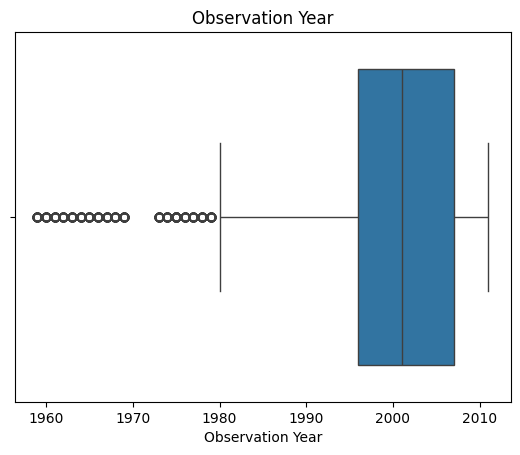

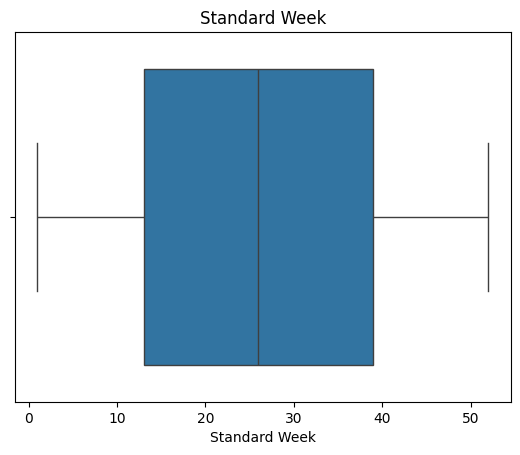

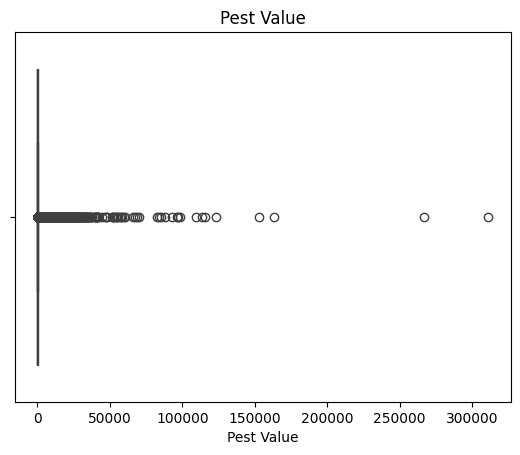

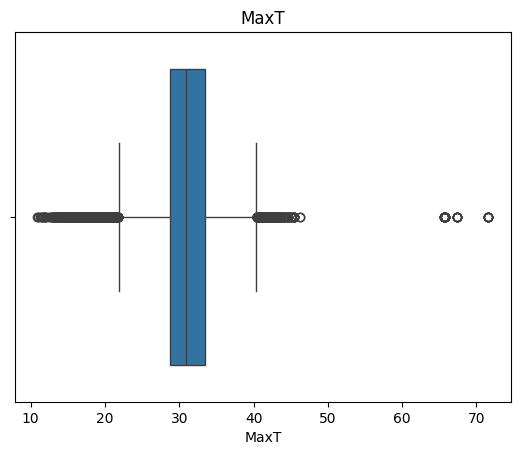

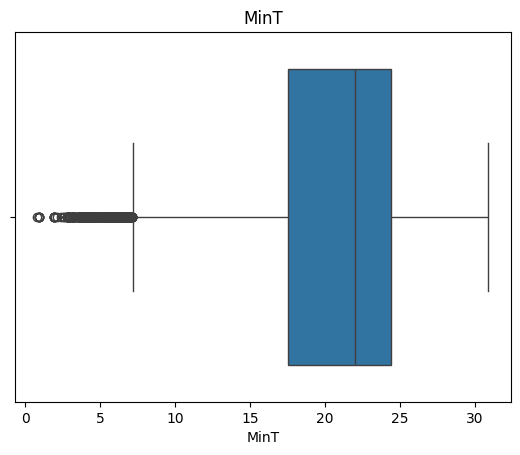

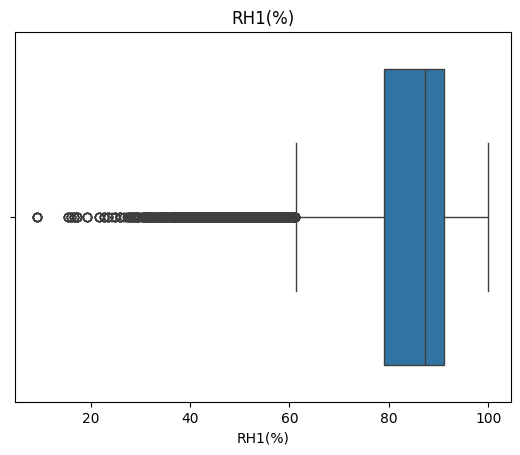

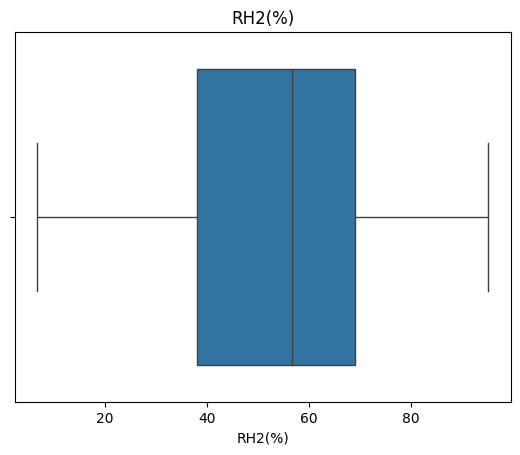

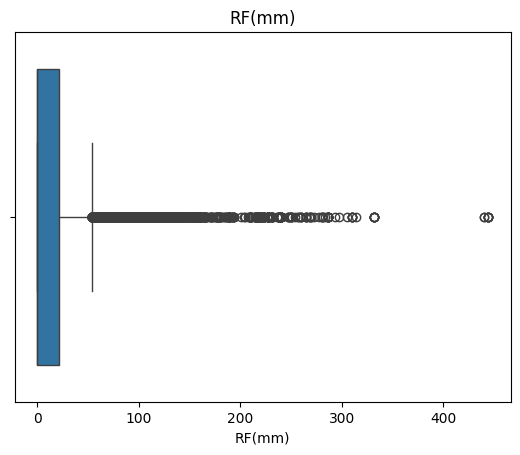

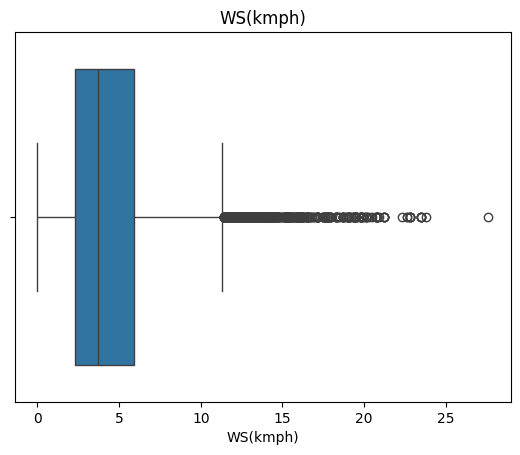

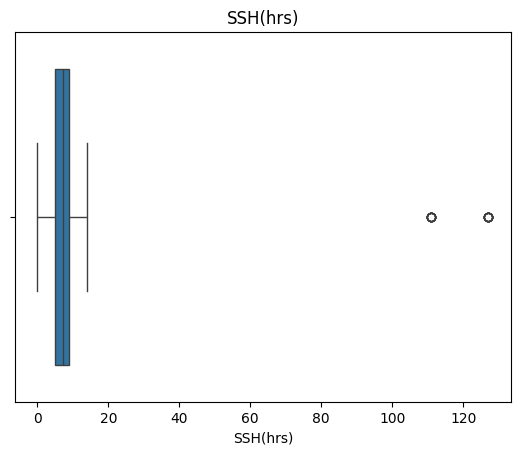

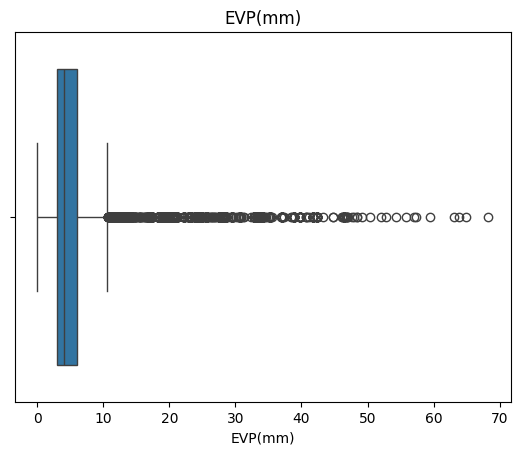

In [25]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [28]:
ols_to_cap = num_cols # Using the previously identified numerical columns

for col in ols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

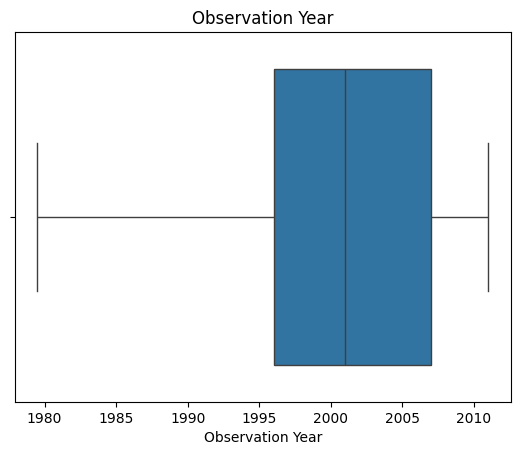

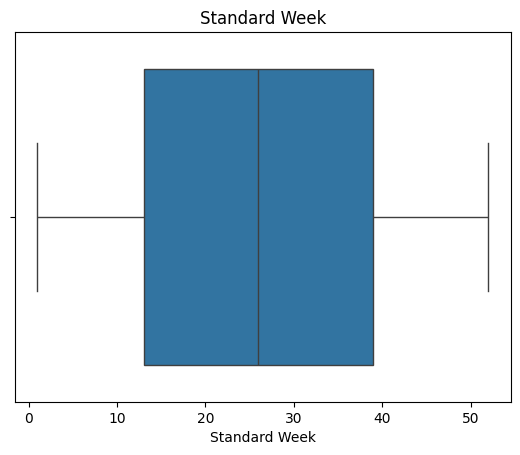

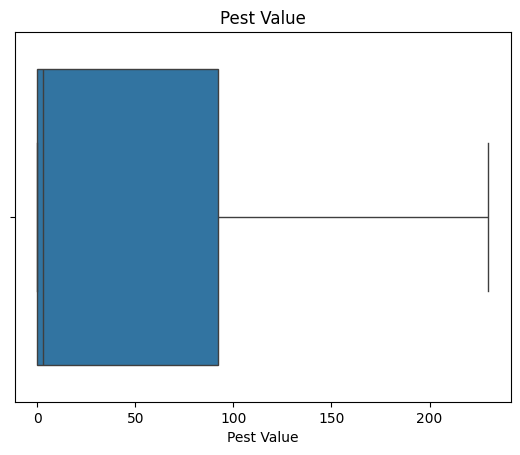

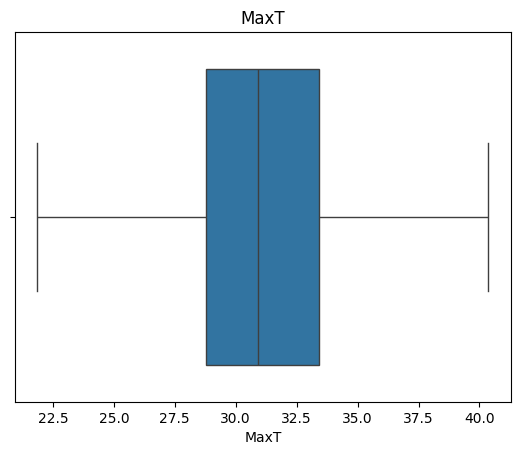

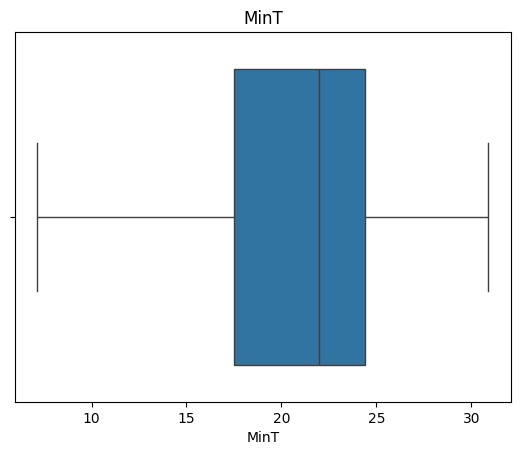

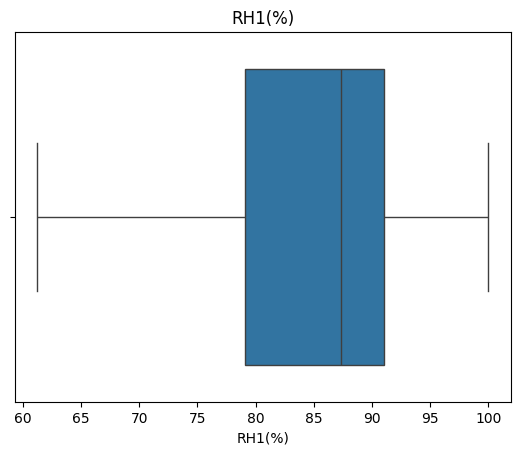

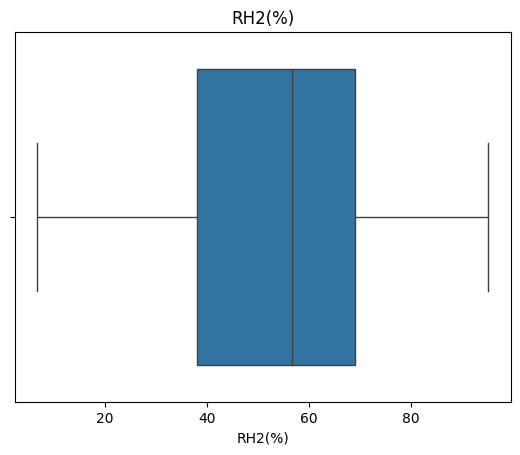

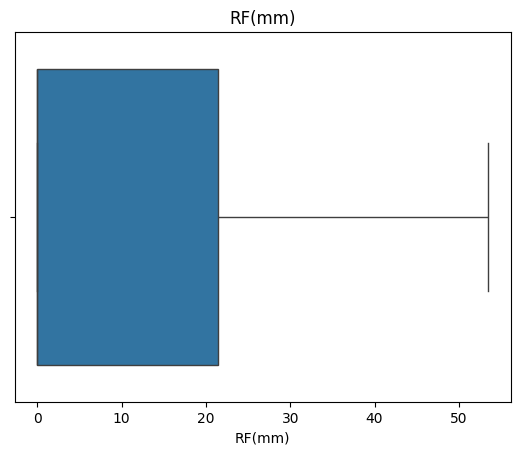

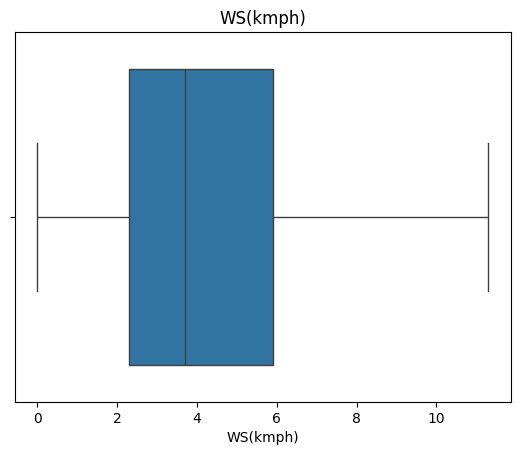

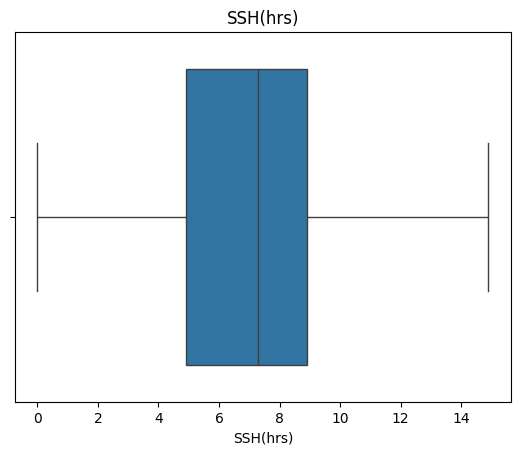

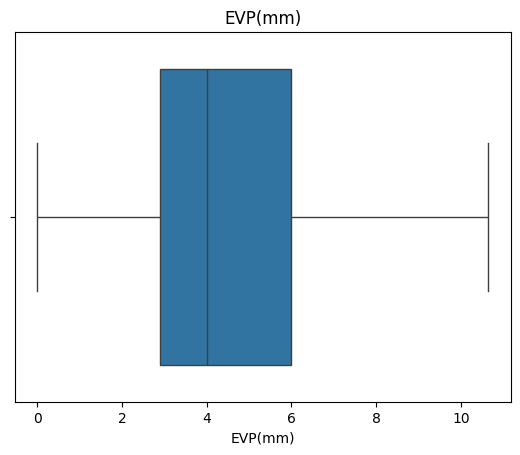

In [29]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [31]:
nominal_cols = ["Collection Type"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [32]:
df.dtypes

,0
Observation Year,float64
Standard Week,int64
Pest Value,float64
MaxT,float64
MinT,float64
RH1(%),float64
RH2(%),float64
RF(mm),float64
WS(kmph),float64
SSH(hrs),float64


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features & target
X = df.drop('Pest Value', axis=1)
y = df['Pest Value']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Select numeric columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Scaling
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [43]:
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd

categorical_cols_to_encode = ['PEST NAME', 'Location']

X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols_to_encode, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols_to_encode, drop_first=True)

train_cols = X_train_encoded.columns
test_cols = X_test_encoded.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_encoded[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_encoded[c] = 0

X_test_encoded = X_test_encoded[train_cols]

knn = KNeighborsRegressor(n_neighbors=8)
knn.fit(X_train_encoded, y_train)

KNeighborsRegressor(n_neighbors=8)

In [46]:
y_pred = knn.predict(X_test_encoded)

In [48]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.5868541384174224